In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from scipy.optimize import brentq
import time
from sklearn.mixture import GaussianMixture

import torch
import torch.nn as nn


from sklearn.preprocessing import StandardScaler

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import KFold

In [ ]:
M_P = 1.6726e-24 # proton mass
CM3_PER_KM3 = 1e15 # 1 km^3 is 1e15 cm^3

In [ ]:
synth = pd.read_csv('./data/Synthetic_F1_55k.csv')
real = pd.read_csv('./data/Real_F1_13.csv')

synth['TT'] = synth['TT'] * 3600
synth['rho'] = synth['rho'] * M_P * CM3_PER_KM3
real['rho'] = real['rho'] * M_P * CM3_PER_KM3

synth.columns, real.columns

(Index(['Unnamed: 0', 'v0', 'mass', 'A', 'rho', 'w', 'gamma', 'a', 'TT'], dtype='object'),
 Index(['Unnamed: 0', 'Start_Date', 'Transit_time', 'v_r', 'Mass', 'rel_wid',
        'A', 'w', 'rho', 'n_pts', 'gamma', 'a'],
       dtype='object'))

In [ ]:
real_cols = ['v_r', 'Mass', 'A', 'rho', 'w']

synth_cols = ['v0', 'mass', 'A', 'rho', 'w']
X = synth[synth_cols].to_numpy(np.float32)
y = synth['TT'].to_numpy(np.float32).reshape(-1, 1)
a = synth['a'].to_numpy(np.float32).reshape(-1, 1)

Xlog = X.copy()
Xlog[:, 1:2] = np.log10(X[:, 1:2])   # mass
Xlog[:, 2:3] = np.log10(X[:, 2:3])   # A
Xlog[:, 3:4] = np.log10(X[:, 3:4])   # rho

N = len(Xlog); rng = np.random.default_rng(0)
perm = rng.permutation(N); ntr = int(0.8 * N)
tr, va = perm[:ntr], perm[ntr:]

xscaler = StandardScaler().fit(Xlog[tr])
y_scale_factor = float(np.std(y[tr]))

def make_ds(idx):
    xs = torch.tensor(xscaler.transform(Xlog[idx]), dtype=torch.float32)
    ys = torch.tensor(y[idx]/y_scale_factor, dtype=torch.float32)
    xu = torch.tensor(X[idx], dtype=torch.float32)
    aa = torch.tensor(a[idx], dtype=torch.float32)
    return TensorDataset(xs, ys, xu, aa)

dl_tr = DataLoader(make_ds(tr), batch_size=256, shuffle=True)
dl_va = DataLoader(make_ds(va), batch_size=512)

In [ ]:
def r_F1(t, a, v0, w, gamma, r0, eps=1e-12):
    # a>0, v0<w ; t in SECONDS, speeds km/s, gamma 1/km
    s      = torch.sqrt(a * gamma)                          # a>0 -> real
    sigma  = torch.atan(torch.sqrt(gamma / a) * (w - v0))
    t_star = sigma / s
    S      = torch.sqrt((a + gamma * (v0 - w)**2) / a)      # +, always real for a>0

    cos_arg = torch.cos(s * t - sigma)
    b1 = w*t + r0 - (1.0/gamma) * torch.log(torch.clamp(S * cos_arg, min=eps))

    e  = torch.exp(2.0 * (s * t - sigma))
    b2 = (w - torch.sqrt(a/gamma))*t + r0 \
          + (1.0/gamma) * (torch.log(torch.clamp((e + 1.0)/(2.0*S), min=eps)) + sigma)

    return torch.where(t <= t_star, b1, b2)


class HeteroLoss(nn.Module):
    def __init__(self, R0_KM, AU_KM, y_scale, lam_phys=0.0):
        super().__init__()
        self.R0, self.AU = R0_KM, AU_KM
        self.C = 100.0
        self.lam_phys = lam_phys
        self.k2 = 1.0 / (AU_KM ** 2)
        self.register_buffer('y_scale', torch.tensor(y_scale, dtype=torch.float32))

    def forward(self, t_hat_s, log_sigma_s, y_true_s, x_unscaled, a):
        inv_var = torch.exp(-2.0 * log_sigma_s)
        nll = 0.5 * inv_var * (t_hat_s - y_true_s).pow(2) + log_sigma_s
        loss = nll.mean()
        if self.lam_phys > 0:
            t_hat = t_hat_s * self.y_scale
            v0  = x_unscaled[:, 0:1]; m = x_unscaled[:, 1:2]
            A   = x_unscaled[:, 2:3]; rho = x_unscaled[:, 3:4]; w = x_unscaled[:, 4:5]
            gamma = (self.C * A * rho) / m
            r_t = r_F1(t_hat, a, v0, w, gamma, self.R0)     # <-- r_F1
            phys = self.k2 * (r_t - self.AU).pow(2)
            loss = loss + self.lam_phys * phys.mean()
        return loss

In [ ]:
class Lampani_model(nn.Module):
    def __init__(self, n_in=5):
        super().__init__()
        self.trunk = nn.Sequential(
            nn.Linear(n_in, 64), nn.SiLU(),
            nn.Linear(64, 64),   nn.SiLU(),
            nn.Linear(64, 32),   nn.SiLU(),
        )
        self.head_t   = nn.Sequential(nn.Linear(32, 1), nn.Softplus())
        self.head_logs = nn.Linear(32, 1)

    def forward(self, x):
        h = self.trunk(x)
        return self.head_t(h), self.head_logs(h)



In [ ]:
model = Lampani_model()
loss_fn = HeteroLoss(R0_KM=20*695_700.0, AU_KM=1.495978707e8,
              y_scale=y_scale_factor, lam_phys=0.0)
opt = torch.optim.Adam(model.parameters(), lr=0.001)

def run_epoch(dl, train):
    model.train() if train else model.eval()
    tot, n = 0.0, 0
    with torch.set_grad_enabled(train):
        for xs, ys, xu, aa in dl:
            t_hat, log_s = model(xs)
            loss = loss_fn(t_hat, log_s, ys, xu, aa)
            if train:
                opt.zero_grad(); loss.backward(); opt.step()
            tot += loss.item() * len(xs); n += len(xs)
    return tot / n

best, patience, wait = np.inf, 60, 0
for epoch in range(500):
    tl = run_epoch(dl_tr, True)
    vl = run_epoch(dl_va, False)
    if vl < best: best, wait, best_state = vl, 0, model.state_dict()
    else:
        wait += 1
        if wait >= patience: print(f"early stop @ {epoch}"); break
    if epoch % 20 == 0: print(f"{epoch}: train {tl:.4f}  val {vl:.4f}")
model.load_state_dict(best_state)

0: train 1.9861  val -0.0700
20: train -0.6429  val -0.6355
40: train -0.6515  val -0.6602
60: train -0.6570  val -0.6544
80: train -0.6564  val -0.6563
100: train -0.6593  val -0.6562
120: train -0.6589  val -0.6555
140: train -0.6619  val -0.6561
160: train -0.6620  val -0.6622
180: train -0.6632  val -0.6538
200: train -0.6631  val -0.6599
220: train -0.6634  val -0.6590
240: train -0.6638  val -0.6600
early stop @ 245


<All keys matched successfully>

In [ ]:
model.eval()
with torch.no_grad():
    Xt = torch.tensor(xscaler.transform(Xlog[va]), dtype=torch.float32)
    t_hat_s, log_s_s = model(Xt)

    pred_h  = (t_hat_s.numpy().flatten() * y_scale_factor) / 3600
    sigma_h = (np.exp(log_s_s.numpy().flatten()) * y_scale_factor) / 3600
    true_h  = y[va].flatten() / 3600

err = pred_h - true_h
mae = np.mean(np.abs(err))
rmse = np.sqrt(np.mean(err**2))
corr = np.corrcoef(pred_h, true_h)[0, 1]
print(f"MAE {mae:.2f} h | RMSE {rmse:.2f} h | corr {corr:.3f}")
print(f"sigma: median {np.median(sigma_h):.2f} h | range {sigma_h.min():.1f}-{sigma_h.max():.1f} h")

MAE 5.79 h | RMSE 8.50 h | corr 0.868
sigma: median 5.59 h | range 0.3-44.8 h


In [ ]:
within_1 = np.mean(np.abs(err) <= 1 * sigma_h)
within_2 = np.mean(np.abs(err) <= 2 * sigma_h)
print(f"calibration:  within 1σ̂ {within_1:.1%} (target ~68%) | within 2σ̂ {within_2:.1%} (target ~95%)")

calibration:  within 1σ̂ 62.5% (target ~68%) | within 2σ̂ 97.2% (target ~95%)


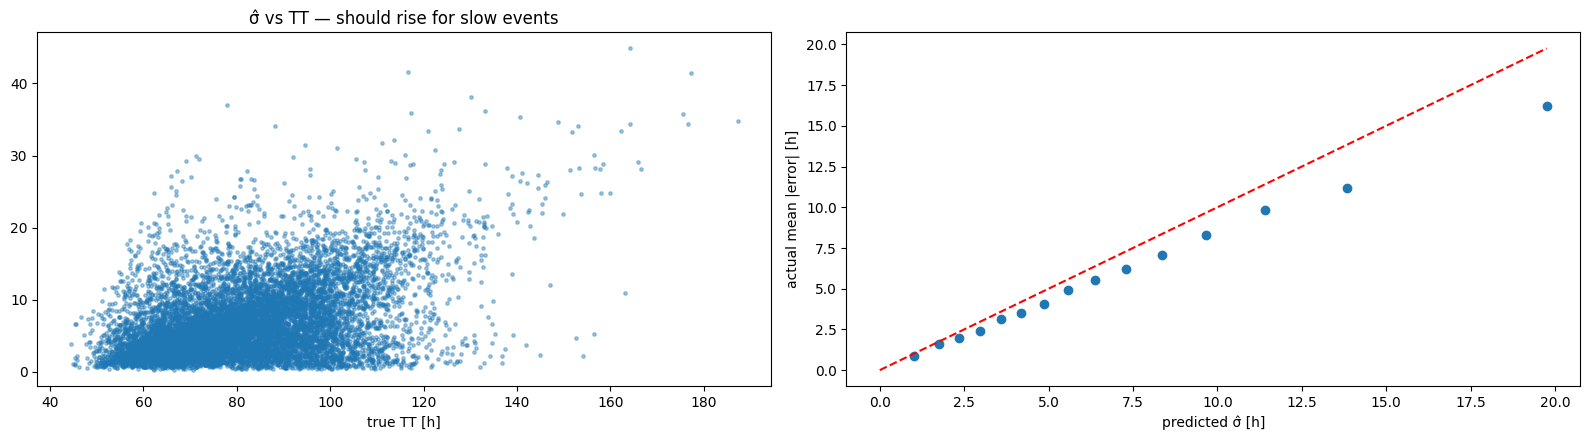

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4.5))

# 2. THE KEY PLOT: does σ̂ grow with TT? confirms it learned the fast=tight/slow=wide structure
ax[0].scatter(true_h, sigma_h, s=6, alpha=0.4)
ax[0].set_xlabel('true TT [h]'); ax[1].set_ylabel('predicted σ̂ [h]')
ax[0].set_title('σ̂ vs TT — should rise for slow events')

# 3. does σ̂ track actual error? bin |error| by σ̂ and compare to ideal
order = np.argsort(sigma_h)
s_sorted, e_sorted = sigma_h[order], np.abs(err)[order]
nb = 15
edges = np.linspace(0, len(s_sorted), nb+1).astype(int)
binned_sig = np.array([s_sorted[edges[i]:edges[i+1]].mean() for i in range(nb)])
binned_err = np.array([e_sorted[edges[i]:edges[i+1]].mean() for i in range(nb)])

plt.scatter(binned_sig, binned_err)
m = max(binned_sig.max(), binned_err.max())
ax[1].plot([0, m], [0, m], 'r--')
ax[1].set_xlabel('predicted σ̂ [h]')
ax[1].set_ylabel('actual mean |error| [h]')
plt.tight_layout()

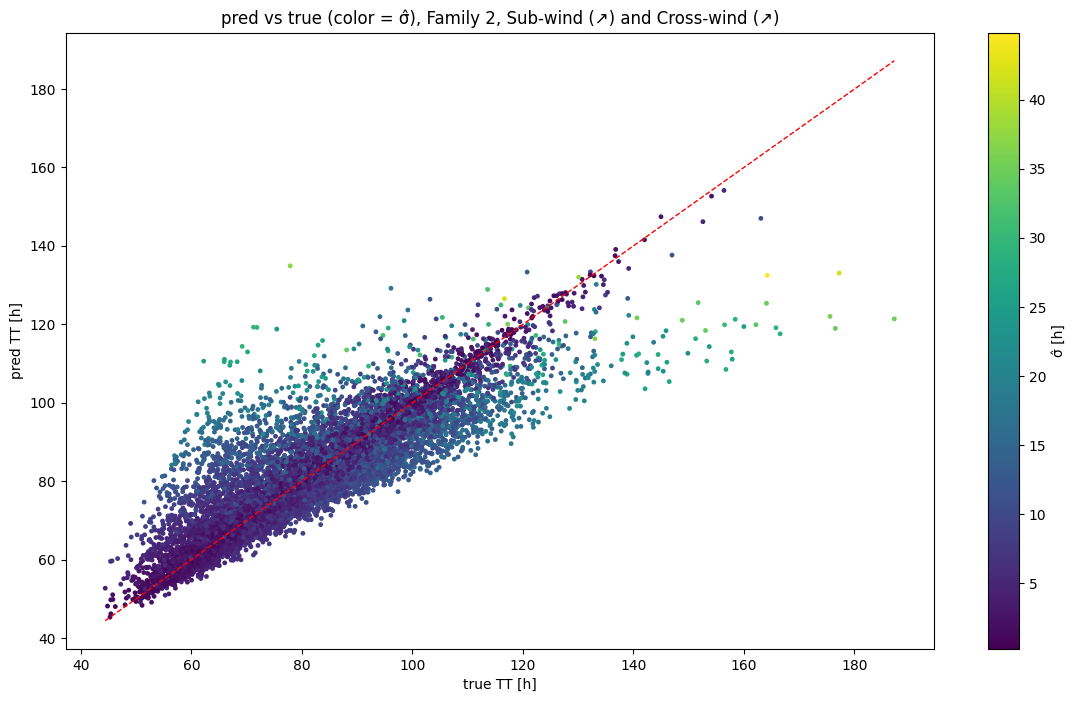

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

sc = ax.scatter(true_h, pred_h, c=sigma_h, s=6, cmap='viridis')
lims = [true_h.min(), true_h.max()]
ax.plot(lims, lims, 'r--', lw=1)
ax.set_xlabel('true TT [h]')
ax.set_ylabel('pred TT [h]')
ax.set_title('pred vs true (color = σ̂), Family 2, Sub-wind (↗) and Cross-wind (↗)')
plt.colorbar(sc, ax=ax, label='σ̂ [h]')

In [ ]:
real_cols = ['v_r', 'Mass', 'A', 'rho', 'w']

Xr = real[real_cols].to_numpy(np.float32)
yr = real['Transit_time'].to_numpy(np.float32).reshape(-1, 1)
ar = real['a'].to_numpy(np.float32).reshape(-1, 1)

Xr_log = Xr.copy()
Xr_log[:, 1] = np.log10(Xr[:, 1])
Xr_log[:, 2] = np.log10(Xr[:, 2])
Xr_log[:, 3] = np.log10(Xr[:, 3])

In [ ]:
def fine_tune_fold(tr_idx, te_idx, pretrained_state, lp, seed, epochs=200, lr=1e-4):
    torch.manual_seed(seed)
    m = Lampani_model(n_in=5)
    m.load_state_dict(pretrained_state)   # start from pretrained
    # for p in m.trunk.parameters(): p.requires_grad = False           # freeze trunk
    opt = torch.optim.Adam([p for p in m.parameters() if p.requires_grad], lr=lr)
    loss_fn = HeteroLoss(20*695_700.0, 1.495978707e8, y_scale_factor, lam_phys=lp)

    # reuse the PRETRAIN xscaler & y_scale_factor — never refit on 79 events
    xs = torch.tensor(xscaler.transform(Xr_log[tr_idx]), dtype=torch.float32)
    ys = torch.tensor(yr[tr_idx]/y_scale_factor, dtype=torch.float32)
    xu = torch.tensor(Xr[tr_idx], dtype=torch.float32)
    aa = torch.tensor(ar[tr_idx], dtype=torch.float32)

    best, wait, best_state = np.inf, 0, None
    for ep in range(epochs):
        m.train()
        t_hat, log_s = m(xs)
        loss = loss_fn(t_hat, log_s, ys, xu, aa)
        opt.zero_grad()
        loss.backward()
        opt.step()
        if loss.item() < best: best, wait, best_state = loss.item(), 0, m.state_dict()
        else:
            wait += 1
            if wait >= 40: break
    m.load_state_dict(best_state)

    # evaluate on held-out fold
    m.eval()
    with torch.no_grad():
        xt = torch.tensor(xscaler.transform(Xr_log[te_idx]), dtype=torch.float32)
        t_hat, log_s = m(xt)
        pred_h  = (t_hat.numpy() * y_scale_factor) / 3600
        sigma_h = (np.exp(log_s.numpy()) * y_scale_factor) / 3600
        true_h  = yr[te_idx] / 3600
    return pred_h.flatten(), true_h.flatten(), sigma_h.flatten()

In [ ]:
from sklearn.model_selection import LeaveOneOut
loo = LeaveOneOut()

for lp in [0, 100, 500, 1000, 2000, 5000]:
    seed_maes = []
    for seed in range(1, 11):
        preds, trues = [], []
        for tr_i, te_i in loo.split(Xr_log):
            p, t, s = fine_tune_fold(tr_i, te_i, best_state, lp, seed=seed)
            preds.append(p); trues.append(t)
        preds = np.concatenate(preds); trues = np.concatenate(trues)
        seed_maes.append(np.mean(np.abs(preds - trues)))
    print(seed_maes)
    print(f"lam_phys={lp}: MAE {np.mean(seed_maes):.2f} ± {np.std(seed_maes):.2f} h")

[np.float32(6.126443), np.float32(6.126443), np.float32(6.126443), np.float32(6.126443), np.float32(6.126443), np.float32(6.126443), np.float32(6.126443), np.float32(6.126443), np.float32(6.126443), np.float32(6.126443)]
lam_phys=0: MAE 6.13 ± 0.00 h
[np.float32(5.8865695), np.float32(5.8865695), np.float32(5.8865695), np.float32(5.8865695), np.float32(5.8865695), np.float32(5.8865695), np.float32(5.8865695), np.float32(5.8865695), np.float32(5.8865695), np.float32(5.8865695)]
lam_phys=100: MAE 5.89 ± 0.00 h
[np.float32(5.7844195), np.float32(5.7844195), np.float32(5.7844195), np.float32(5.7844195), np.float32(5.7844195), np.float32(5.7844195), np.float32(5.7844195), np.float32(5.7844195), np.float32(5.7844195), np.float32(5.7844195)]
lam_phys=500: MAE 5.78 ± 0.00 h
[np.float32(5.761433), np.float32(5.761433), np.float32(5.761433), np.float32(5.761433), np.float32(5.761433), np.float32(5.761433), np.float32(5.761433), np.float32(5.761433), np.float32(5.761433), np.float32(5.761433)]
la

In [ ]:
def scratch_fold(tr_idx, te_idx, lp, seed, epochs=400, lr=1e-3):
    torch.manual_seed(seed)
    m = Lampani_model(n_in=5)                       # FRESH random weights, no load_state_dict
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    loss_fn = HeteroLoss(20*695_700.0, 1.495978707e8, y_scale_factor, lam_phys=lp)

    # fit scaler on THIS fold's train (no pretrain scaler to borrow)
    xsc = StandardScaler().fit(Xr_log[tr_idx])
    ysf = float(np.std(yr[tr_idx]))
    xs = torch.tensor(xsc.transform(Xr_log[tr_idx]), dtype=torch.float32)
    ys = torch.tensor(yr[tr_idx]/ysf, dtype=torch.float32)
    xu = torch.tensor(Xr[tr_idx], dtype=torch.float32)
    aa = torch.tensor(ar[tr_idx], dtype=torch.float32)

    best, wait, bs = np.inf, 0, None
    for ep in range(epochs):
        m.train()
        t_hat, log_s = m(xs)
        loss = loss_fn(t_hat, log_s, ys, xu, aa)
        opt.zero_grad(); loss.backward(); opt.step()
        if loss.item() < best: best, wait, bs = loss.item(), 0, m.state_dict()
        else:
            wait += 1
            if wait >= 50: break
    m.load_state_dict(bs); m.eval()
    with torch.no_grad():
        xt = torch.tensor(xsc.transform(Xr_log[te_idx]), dtype=torch.float32)
        t_hat, _ = m(xt)
        pred = (t_hat.numpy().flatten()*ysf)/3600
    return pred, yr[te_idx].flatten()/3600


In [ ]:
for lp in [0, 100, 500, 1000, 2000, 5000]:
    seed_maes = []
    for seed in range(1, 11):
        P, T = [], []
        for tr_i, te_i in loo.split(Xr_log):
            p, t = scratch_fold(tr_i, te_i, lp, seed=seed)
            P.append(p); T.append(t)
        P, T = np.concatenate(P), np.concatenate(T)
        seed_maes.append(np.mean(np.abs(P - T)))
    print(f"lam_phys={lp}: MAE {np.mean(seed_maes):.2f} ± {np.std(seed_maes):.2f} h")